In [1]:
from google.colab import files
uploaded = files.upload()

Saving soumya.txt to soumya.txt


In [2]:
with open('soumya.txt', 'r', encoding='utf-8') as f:
    text = f.read().lower()

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Embedding

In [4]:
with open('soumya.txt', 'r', encoding='utf-8') as f:
    text = f.read().lower()

In [5]:
chars = sorted(set(text))
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for c, i in char_to_int.items()}

In [6]:
seq_length = 40
sequences = []
next_chars = []

for i in range(len(text) - seq_length):
    sequences.append([char_to_int[c] for c in text[i:i+seq_length]])
    next_chars.append(char_to_int[text[i+seq_length]])

sequences = np.array(sequences)
next_chars = np.array(next_chars)

In [7]:
X = sequences
y = to_categorical(next_chars, num_classes=len(chars))

In [8]:
from tensorflow.keras.layers import GRU

model = Sequential([
    Embedding(input_dim=len(chars), output_dim=50, input_length=seq_length),
    GRU(128, return_sequences=False),
    Dense(len(chars), activation="softmax")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [11]:
model.fit(X, y, epochs=10, batch_size=64)
model.fit(X, y, epochs=20, batch_size=64)
model.fit(X, y, epochs=30, batch_size=64)
model.fit(X, y, epochs=40, batch_size=64)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.1844 - loss: 2.9725
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.2597 - loss: 2.6062
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.2744 - loss: 2.4568
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.2828 - loss: 2.3938
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.2976 - loss: 2.3251
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.3267 - loss: 2.2526
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.3310 - loss: 2.2529
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.3423 - loss: 2.1640
Epoch 9/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.3768 - loss: 2.0720
Epoch 10/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.3794 - loss: 2.0559
Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.3931 - loss: 2.0169
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accura

174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
Accuracy: 0.9998194293968942

Classification Report:
              precision    recall  f1-score   support

           
       1.00      1.00      1.00       137
                   1.00      1.00      1.00       823
           "       1.00      1.00      1.00         4
           ,       1.00      1.00      1.00        63
           -       1.00      1.00      1.00         7
           .       1.00      1.00      1.00       121
           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         3
           :       1.00      1.00      1

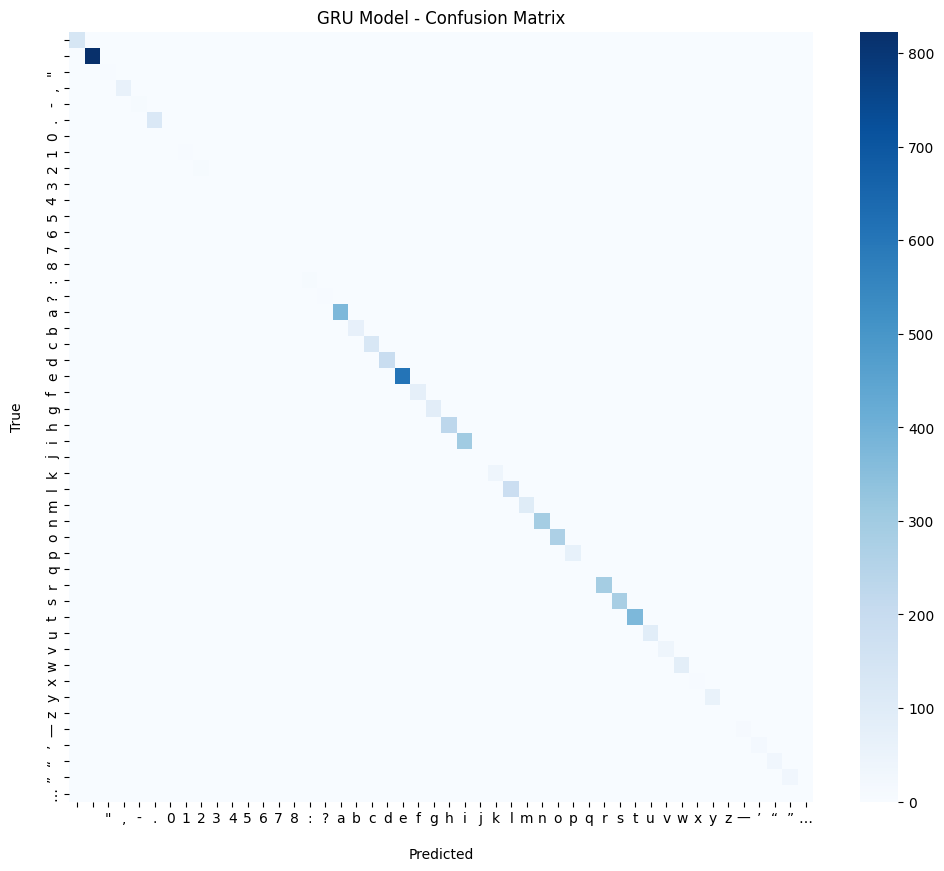

In [12]:
!pip install scikit-learn
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Embedding
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


y_pred_probs = model.predict(X)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[int_to_char[i] for i in range(len(chars))]))

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, cmap="Blues", xticklabels=chars, yticklabels=chars, fmt='d')
plt.title("GRU Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [13]:
def generate_text(seed_text, length=200):
    result = seed_text
    for _ in range(length):
        input_seq = [char_to_int.get(char, 0) for char in seed_text[-seq_length:]]
        # Pad the input sequence if it's shorter than seq_length
        input_seq = pad_sequences([input_seq], maxlen=seq_length, padding='pre', value=0)[0]
        input_seq = np.array(input_seq).reshape(1, seq_length)
        predicted_index = np.argmax(model.predict(input_seq, verbose=0))
        predicted_char = int_to_char[predicted_index]
        result += predicted_char
        seed_text += predicted_char
    return result

In [14]:
seed_text = "in the year 2146, earth was silent."
generated = generate_text(seed_text, length=200)
print("\nGenerated Text:\n", generated)


Generated Text:
 in the year 2146, earth was silent.

the once blue planet, home to billions, now floated like a forgotten pearl in the cosmic sea. a technological catastrophe had rendered its surface uninhabitable, driving humanity to scatter across t


In [15]:
# Import necessary library for data splitting
from sklearn.model_selection import train_test_split

# ... (Your existing code for data preparation) ...

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)  # Adjust test_size and random_state as needed

# Define a function to train and validate the model for different epoch counts
def train_and_validate(model, X_train, y_train, X_val, y_val, epochs):
    print(f"Training for {epochs} epochs...")
    history = model.fit(
        X_train, y_train,                      # Training data
        epochs=epochs,                         # Number of epochs
        batch_size=32,                         # Batch size
        validation_data=(X_val, y_val),        # Validation data
        validation_freq=1,                     # Run validation every epoch
        verbose=1                               # Show training progress
    )
    return history

# Train for 10 epochs
history_10 = train_and_validate(model, X_train, y_train, X_val, y_val, 10)

# Train for 20 epochs
history_20 = train_and_validate(model, X_train, y_train, X_val, y_val, 20)

# Train for 30 epochs
history_30 = train_and_validate(model, X_train, y_train, X_val, y_val, 30)

# Train for 40 epochs
history_40 = train_and_validate(model, X_train, y_train, X_val, y_val, 40)

Training for 10 epochs...
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.9486 - loss: 0.2060 - val_accuracy: 0.6038 - val_loss: 1.4382
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.7030 - loss: 1.0287 - val_accuracy: 0.7491 - val_loss: 0.7983
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.8862 - loss: 0.3546 - val_accuracy: 0.8132 - val_loss: 0.6068
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9605 - loss: 0.1644 - val_accuracy: 0.8312 - val_loss: 0.5104
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9889 - loss: 0.0894 - val_accuracy: 0.8457 - val_loss: 0.4440
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9987 - loss: 0.0482 - val_accuracy: 0.8484 - val_loss: 0.4280
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.9987 - loss: 0.0376 - val_accuracy: 0.8583 - val_loss: 0.4069
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.9

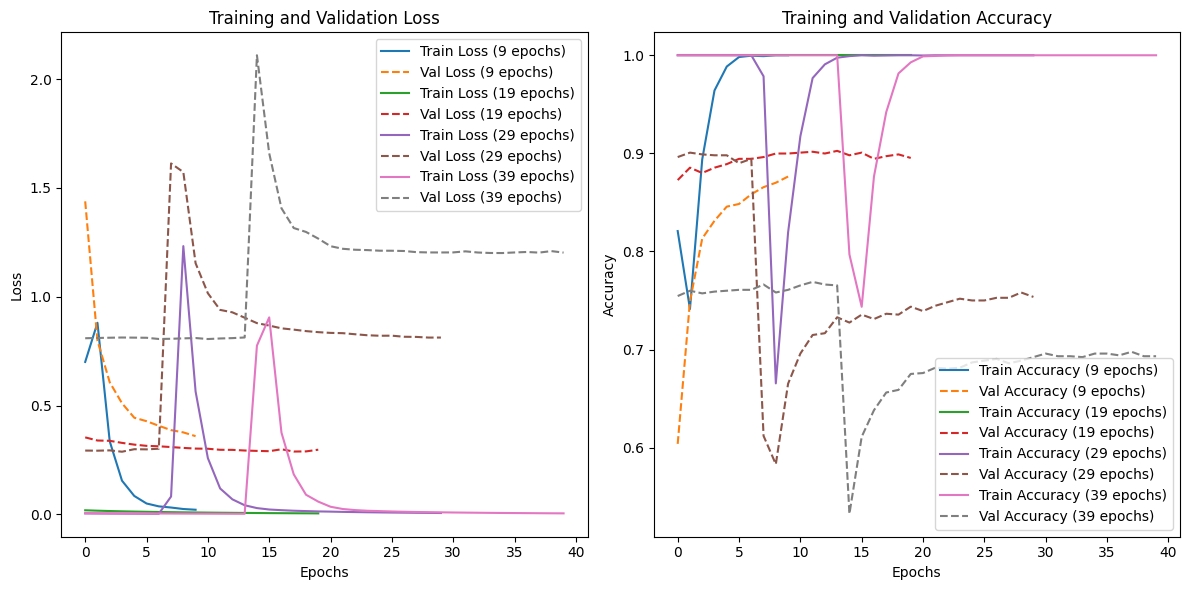

In [16]:
import matplotlib.pyplot as plt

# Function to plot training and validation loss and accuracy
def plot_training_history(histories):
    plt.figure(figsize=(12, 6))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    for history in histories:
        plt.plot(history.history['loss'], label=f'Train Loss ({history.epoch[-1]} epochs)')
        plt.plot(history.history['val_loss'], label=f'Val Loss ({history.epoch[-1]} epochs)', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    for history in histories:
        plt.plot(history.history['accuracy'], label=f'Train Accuracy ({history.epoch[-1]} epochs)')
        plt.plot(history.history['val_accuracy'], label=f'Val Accuracy ({history.epoch[-1]} epochs)', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Combine all histories (for 10, 20, 30, 40 epochs)
histories = [history_10, history_20, history_30, history_40]

# Plot the results
plot_training_history(histories)